# ML Zoomcamp 2026 — Homework 2

Official: `materials/homework.md` (do not edit).
Data: `data/car_fuel_efficiency_2026.csv` (2026 pinned release).
Write-up: `ML_02_HW.md`.

Kernel: **ML Zoomcamp** / this folder `.venv`. Do not use `!pip`.


## 0) Imports


In [1]:
import os
os.environ.setdefault(r"MPLCONFIGDIR", r"E:\IT_SPACES\AI\.cache\matplotlib")
os.environ.setdefault(r"XDG_CACHE_HOME", r"E:\IT_SPACES\AI\.cache")
os.environ.setdefault(r"TEMP", r"E:\IT_SPACES\AI\.cache\tmp")
os.environ.setdefault(r"TMP", r"E:\IT_SPACES\AI\.cache\tmp")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd


## 1) Load data


In [2]:
# TODO: load the pinned 2026 CSV and keep only the five homework columns
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

cols = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg",
]

df = df[cols]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA — fuel_efficiency_mpg tail?


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64


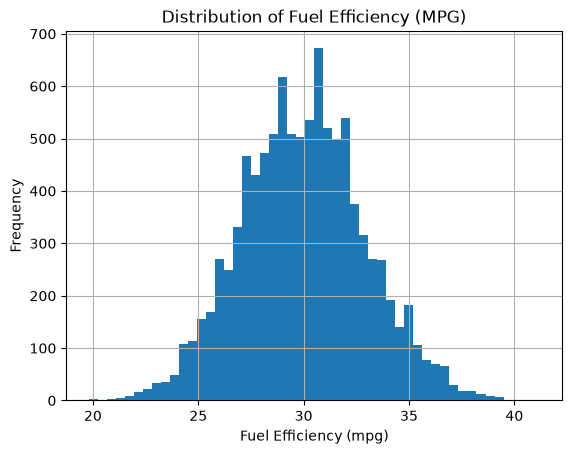

In [3]:
# TODO: check whether fuel_efficiency_mpg has a long tail (histogram / describe)

import matplotlib.pyplot as plt

print(df['fuel_efficiency_mpg'].describe())
df['fuel_efficiency_mpg'].hist(bins=50)
plt.title("Distribution of Fuel Efficiency (MPG)")
plt.xlabel("Fuel Efficiency (mpg)")
plt.ylabel("Frequency")

plt.show()

## Q1 — Missing column


In [4]:
# TODO: how many missing values per column; which one column has missing values
df.isnull().sum()



engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2 — Horsepower median


In [5]:
# TODO: median (50th percentile) of horsepower; pick the matching option
hp_median = df['horsepower'].median()
print(hp_median)

254.0


## Q3 — Fill NA with 0 vs mean (RMSE)


In [6]:
# TODO: fill Q1 NA with 0 vs train-only mean; compare validation RMSE rounded to 3 decimals
# Calculate the total number of data points and the split points for a 60%, 20%, 20% division.
n = len(df)
n_val = int(n * 0.2)  # Validation set size (20%)
n_test = int(n * 0.2) # Test set size (20%)
n_train = n - n_val - n_test  # Training set size (60%)

# Set the random seed to 42 for reproducibility and shuffle the indices.
np.random.seed(42)
idx = np.arange(n)  # Generate a contiguous array of integers from 0 to n-1.
np.random.shuffle(idx)

# Split the data into training, validation, and test sets based on the shuffled indices.
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Extract the target variable (fuel_efficiency_mpg) as NumPy arrays.
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

# Specify the 4 feature columns to be used for model training.
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']


# Train linear regression weights using the Normal Equation.
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])          # Generate a column of ones for the bias term.
    X = np.column_stack([ones, X])      # Prepend the column of ones to the feature data.
    XTX = X.T.dot(X)                    # Compute the dot product of the transposed matrix and the matrix.
    XTX_inv = np.linalg.inv(XTX)        # Compute the inverse of the matrix.
    w_full = XTX_inv.dot(X.T).dot(y)    # Calculate the optimal weights (w).
    return w_full[0], w_full[1:]        # Return the bias (w0) and the remaining feature weights separately.

# Evaluate the prediction error (RMSE) of the model.
def rmse(y, y_pred):
    se = (y - y_pred) ** 2              # Square the differences between actual and predicted values.
    mse = se.mean()                     # Calculate the mean of the squared errors.
    return np.sqrt(mse)                 # Return the square root of the MSE (RMSE).


# Extract feature columns and fill missing values with a specified fill value.
def prepare_X(df_part, fill):
    df_num = df_part[base].copy()       # Copy the specified 4 features.
    df_num = df_num.fillna(fill)        # Fill missing values (NaN) with the provided fill value.
    return df_num.values                # Convert to a NumPy array for calculations.

# Precompute the horsepower mean exclusively from the training set to prevent data leakage.
mean_hp = df_train.horsepower.mean()

# Case 1: Filling missing values with 0
X_train_0 = prepare_X(df_train, 0)                  # Fill training set missing values with 0.
w0, w = train_linear_regression(X_train_0, y_train) # Train the linear regression model.
X_val_0 = prepare_X(df_val, 0)                      # Fill validation set missing values with 0.
rmse_0 = round(rmse(y_val, w0 + X_val_0.dot(w)), 3) # Calculate the validation RMSE.

# Case 2: Filling missing values with the training set mean
X_train_m = prepare_X(df_train, mean_hp)            # Fill training set missing values with the mean.
w0, w = train_linear_regression(X_train_m, y_train) # Train the linear regression model.
X_val_m = prepare_X(df_val, mean_hp)                # Fill validation set missing values with the training mean.
rmse_m = round(rmse(y_val, w0 + X_val_m.dot(w)), 3) # Calculate the validation RMSE.

# Print and compare the final results.
print(f"RMSE (Filled with 0): {rmse_0}")
print(f"RMSE (Filled with mean): {rmse_m}")

RMSE (Filled with 0): 2.205
RMSE (Filled with mean): 2.202


## Q4 — Regularization r


In [7]:
# Define the linear regression training function with regularization.
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    # Generate a column of ones for the intercept calculation.
    X = np.column_stack([ones, X])
    # Prepend the column of ones to the feature data.
    XTX = X.T.dot(X)
    # Multiply the transposed matrix by the original matrix.
    XTX = XTX + r * np.eye(XTX.shape[0])
    # Add the regularization parameter r to the diagonal elements.
    XTX_inv = np.linalg.inv(XTX)
    # Compute the inverse of the regularized matrix.
    w_full = XTX_inv.dot(X.T).dot(y)
    # Calculate the final optimal weights w.
    return w_full[0], w_full[1:]
    # Separate and return w0 (intercept) and the remaining feature weights.

# Iterate through the specified r values and measure the validation RMSE.
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train, 0)
    # Preprocess the training set by filling missing values with 0.
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    # Train the model with regularization applied.
    X_val = prepare_X(df_val, 0)
    # Preprocess the validation set by also filling missing values with 0.
    score = round(rmse(y_val, w0 + X_val.dot(w)), 4)
    # Calculate the validation RMSE and round to 4 decimal places.
    print(f"r={r:<5} -> RMSE: {score}")
    # Print the validation RMSE score for each r value.

r=0     -> RMSE: 2.2053
r=0.01  -> RMSE: 2.2058
r=0.1   -> RMSE: 2.2241
r=1     -> RMSE: 2.3492
r=5     -> RMSE: 2.4094
r=10    -> RMSE: 2.4195
r=100   -> RMSE: 2.4292


## Q5 — Seed sensitivity (std of RMSE)


In [16]:
# TODO: seeds 0-9, fill NA with 0, no regularization; np.std of val RMSEs rounded to 3 decimals

scores = []
# Initialize an empty list to store the validation RMSE score for each seed.

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# Define a list of seed values from 0 to 9 to iterate through.

for s in seeds:
    # Iterate over each seed value in the seeds list.
    
    np.random.seed(s)
    # Set the random seed to the current value of s for reproducibility.
    
    idx = np.arange(n)
    # Create an index array from 0 to n-1.
    
    np.random.shuffle(idx)
    # Randomly shuffle the index array.
    
    df_train = df.iloc[idx[:n_train]]
    # Extract the training set based on shuffled indices.
    
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    # Extract the validation set based on shuffled indices.
    
    y_train = df_train.fuel_efficiency_mpg.values
    # Extract the target values for the training set.
    
    y_val = df_val.fuel_efficiency_mpg.values
    # Extract the target values for the validation set.
    
    X_train = prepare_X(df_train, 0)
    # Prepare the training feature matrix with missing values filled with 0.
    
    w0, w = train_linear_regression(X_train, y_train)
    # Train the linear regression model without regularization and obtain bias and weights.
    
    X_val = prepare_X(df_val, 0)
    # Prepare the validation feature matrix with missing values filled with 0.
    
    scores.append(rmse(y_val, w0 + X_val.dot(w)))
    # Calculate the validation RMSE and append it to the scores list.

round(np.std(scores), 3)
# Compute the standard deviation of the validation RMSE scores and round it to three decimal places.

np.float64(0.029)

## Q6 — Test RMSE (seed 9, r=0.001)


In [14]:
# TODO: seed 9, train+val combined, fill NA with 0, r=0.001; test RMSE matching an option

np.random.seed(9)
# Fix the seed to 9 to reproduce the exact same results during random sampling.

n = len(df)
# Save the total number of rows in the dataset to variable n.

n_val = int(0.2 * n)
# Set 20% of the total data as the validation set size.

n_test = int(0.2 * n)
# Set 20% of the total data as the test set size.

n_train = n - n_val - n_test
# Set the remaining 60% excluding validation and test as the training set size.

idx = np.arange(n)
# Create an index array from 0 to n-1.

np.random.shuffle(idx)
# Randomly shuffle the index array.

df_train = df.iloc[idx[:n_train]].copy()
# Extract the first 60% as the training set based on shuffled indices.

df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
# Extract the next 20% as the validation set based on shuffled indices.

df_test = df.iloc[idx[n_train + n_val:]].copy()
# Extract the remaining 20% as the test set based on shuffled indices.

df_train = df_train.reset_index(drop=True)
# Reset the training set indices starting from 0.

df_val = df_val.reset_index(drop=True)
# Reset the validation set indices starting from 0.

df_test = df_test.reset_index(drop=True)
# Reset the test set indices starting from 0.

y_test = df_test.fuel_efficiency_mpg.values
# Extract the target value fuel_efficiency_mpg from the test set.

df_full_train = pd.concat([df_train, df_val])
# Concatenate the training and validation sets vertically.

df_full_train = df_full_train.reset_index(drop=True)
# Reset the indices of the combined dataframe sequentially from 0.

X_full_train = prepare_X(df_full_train, 0)
# Generate the full training feature matrix with missing values filled with 0.

y_full_train = df_full_train.fuel_efficiency_mpg.values
# Extract the target value fuel_efficiency_mpg from the full training data.

w_0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
# Train the model using regularized linear regression with regularization parameter r=0.001.

X_test = prepare_X(df_test, 0)
# Prepare the feature matrix for the test set with missing values filled with 0.

y_pred = w_0 + X_test.dot(w)
# Calculate final predictions by multiplying test features with learned weights and adding the bias.

score = rmse(y_test, y_pred)
# Compute the RMSE between the actual test targets and predictions.

print(round(score, 3))
# Print the final RMSE rounded to three decimal places.

2.236
